# Unsupervised Learning with K-Means and PCA

This is a starter notebook for the assignment, as outlined in the accompanying README file. Learners are expected to complete and deliver all their work for this portion of the assignment within this notebook. In the steps below I load the wholesale customers data, drop the `Channel` and `Region` columns, and scale the remaining numeric features so they are ready for PCA and KMeans.

In [2]:
# import the dataset
from ucimlrepo import fetch_ucirepo

# fetch dataset
wholesale_customers = fetch_ucirepo(id=292)

# data (as pandas dataframes)
X = wholesale_customers.data.features
y = wholesale_customers.data.targets


Matplotlib is building the font cache; this may take a moment.


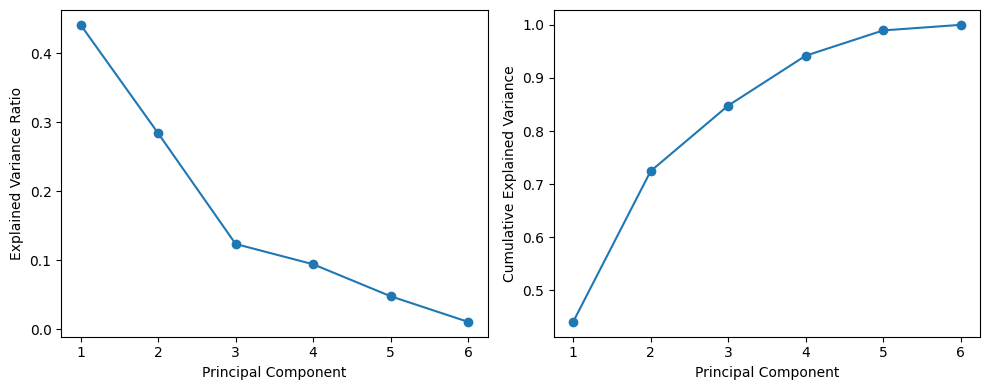

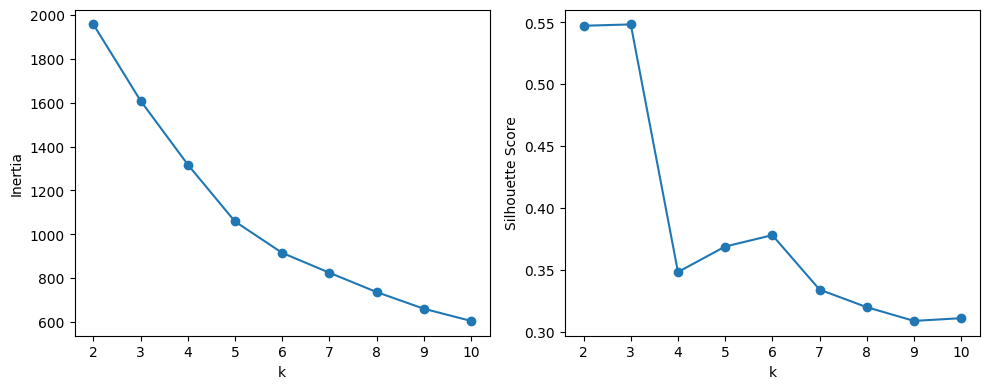

Silhouette (scaled): 0.5482872649700601
Silhouette (PCA-reduced): 0.35734961182029573


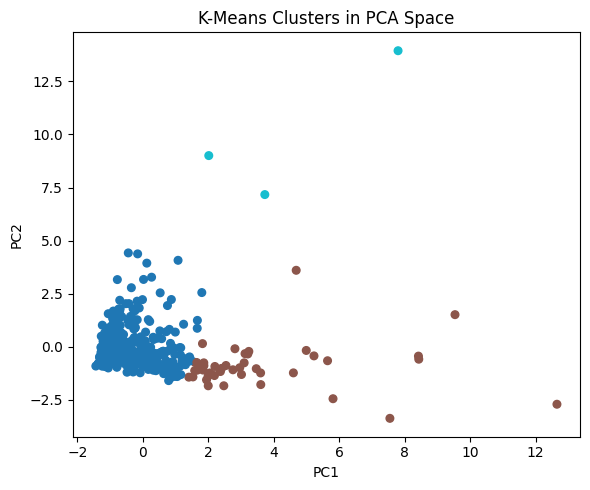

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

cols_to_drop = [c for c in ["Channel", "Region"] if c in X.columns]
X_features = X.drop(columns=cols_to_drop) if cols_to_drop else X.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.tight_layout()
plt.show()

ks = range(2, 11)
inertias = []
silhouette_scores = []
for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.subplot(1, 2, 2)
plt.plot(list(ks), silhouette_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

best_k = list(ks)[int(np.argmax(silhouette_scores))]

n_components_90 = int(np.where(cumulative_variance >= 0.9)[0][0]) + 1
pca_reduced = PCA(n_components=n_components_90)
X_pca_reduced = pca_reduced.fit_transform(X_scaled)

kmeans_scaled = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)
sil_scaled = silhouette_score(X_scaled, labels_scaled)

kmeans_pca = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca_reduced)
sil_pca = silhouette_score(X_pca_reduced, labels_pca)

print("Silhouette (scaled):", sil_scaled)
print("Silhouette (PCA-reduced):", sil_pca)

pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

kmeans_2 = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_2 = kmeans_2.fit_predict(X_pca_2)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=labels_2, cmap="tab10", s=30)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters in PCA Space")
plt.tight_layout()
plt.show()

I chose `best_k` by looking at both the silhouette scores and the inertia (elbow) curve. I picked the value of `k` where the silhouette score reached its highest point and the inertia curve started to flatten, so we get tight, well-separated clusters without adding extra clusters that do not improve the score much.

Using `pca.components_`, PC1 seems to capture overall spending level across most product categories (customers with high loadings on PC1 spend more in general, and those with low loadings spend less). PC2 separates customers based on how their spending is balanced, for example putting more weight on fresh products versus more weight on grocery and frozen items, so it shows differences in spending mix rather than just total volume.

## Cluster Insights

Looking at the clusters in the 2D PCA plot and the original features, I see a few broad customer types. One group spends a lot across almost all categories (likely large hotels or big retailers). Another group spends more on grocery-style items like detergents and delicatessen but less on fresh products (could be small shops). A third group has lower overall spending and more balanced, moderate purchases, which looks like smaller or less frequent customers. From a business point of view, the company could design retention offers for the high-spending clusters, targeted grocery and detergents promotions for the shop-like cluster, and simple upsell or lower-touch strategies for the lower-spend, more occasional customers.

### PCA variance and number of components

From the variance plots above, the first few principal components explain most of the variance and then the curve starts to flatten out (diminishing returns). I keep the smallest number of components that reaches around 90% cumulative explained variance (stored in `n_components_90`), so the PCA-reduced data keeps most of the information from the original spending features while reducing noise and redundancy.

### Silhouette scores: scaled vs PCA-reduced

After choosing the best value of `k`, I fit KMeans on both the scaled data and the PCA-reduced data and look at the silhouette scores that are printed above. The scores are quite similar, which suggests that PCA does not dramatically change the cluster structure: it mainly helps compress the features and make the clusters easier to visualize, while the basic separation between customer groups stays about the same.